In [ ]:
from pathlib import Path
import re
from collections import defaultdict
import pandas as pd
import numpy as np

# exp_regex = r"\d{8}_\d{6}_exp_load_solver_(iterative|stable_point)_(\d+\.\d+)_(\d+)"
# exp_regex = r"\d{8}_\d{6}_exp_layer_budget_(\d+)_(\d+)__width_50$"
# exp_regex = r"\d{8}_\d{6}_exp_layer_budget_(\d+)_(\d+)_20width$"
# exp_regex = r"\d{8}_\d{6}_exp_ratio_(\d+)_(\d+)_(\d+)_(\d+)$"
exp_regex = r"\d{8}_\d{6}_exp_main_(sink_many|sink_one)_(\d+\.\d+)_(\d+)$"

folder = Path(".").resolve() / "experiments"

# experiment_metrics = ["layer", "variation"]
# experiment_metrics = ["b", "c", "d", "variation"]
experiment_metrics = ["solver", "load_lambda", "variation"]

run_metrics = {
    "accuracy.txt": "accuracy",
    "power_entropy.txt": "pentropy",
    "speaker_entropy.txt": "sentropy",
}


columns = defaultdict(list)

for ent in folder.iterdir():

    if not ent.is_dir():
        continue

    res = re.findall(exp_regex, ent.name)
    if len(res) == 0:
        continue

    n_items = None
    for filename, name in run_metrics.items():

        with open(ent / filename, "r") as f:
            values = [float(v) for v in f.readlines()]

        n_items = len(values)
        columns[name].extend(values)


    for name, value in zip(experiment_metrics, res[0], strict=True):
        columns[name].extend([value] * n_items)

    columns["t"].extend(range(n_items))

    with open(ent / "test_metrics.txt", "r") as f:
        for line in f:
            name, metric = line.replace(" ", "").split("=")
            test_name = f"test_{name}"
            metric = float(metric)
            columns[test_name].extend([metric] * n_items)


df = pd.DataFrame(columns)
df["variation"] = pd.to_numeric(df["variation"])

if "layer" in df.columns:
    df["layer"] = pd.to_numeric(df["layer"])


if "b" in df.columns:

    df["ratio"] = df["b"] + ":" +  df["c"] + ":" +  df["d"]

    df["b"] = pd.to_numeric(df["b"])
    df["c"] = pd.to_numeric(df["c"])
    df["d"] = pd.to_numeric(df["d"])

if "load_lambda" in df.columns:

    df["load_lambda"] = pd.to_numeric(df["load_lambda"])



In [117]:
df.sample(5)

,accuracy,pentropy,sentropy,solver,load_lambda,variation,t,test_accuracy,test_power_entropy,test_speaker_entropy,test_region_nmi
21721,0.9138,0.1753,0.9137,sink_many,0.464159,0,121,0.9288,0.158210,0.937431,0.266263
31843,0.8467,0.3603,0.9605,sink_many,1.000000,2,43,0.8957,0.181605,0.927885,0.115855
6381,0.8580,0.3766,0.9614,sink_one,0.146780,5,81,0.8745,0.367778,0.982490,0.109594
20965,0.9083,0.2848,0.9848,sink_one,0.464159,5,265,0.9198,0.274180,0.979741,0.097057
3388,0.8713,0.2319,0.7844,sink_many,0.100000,3,88,0.9206,0.196496,0.852357,0.198947


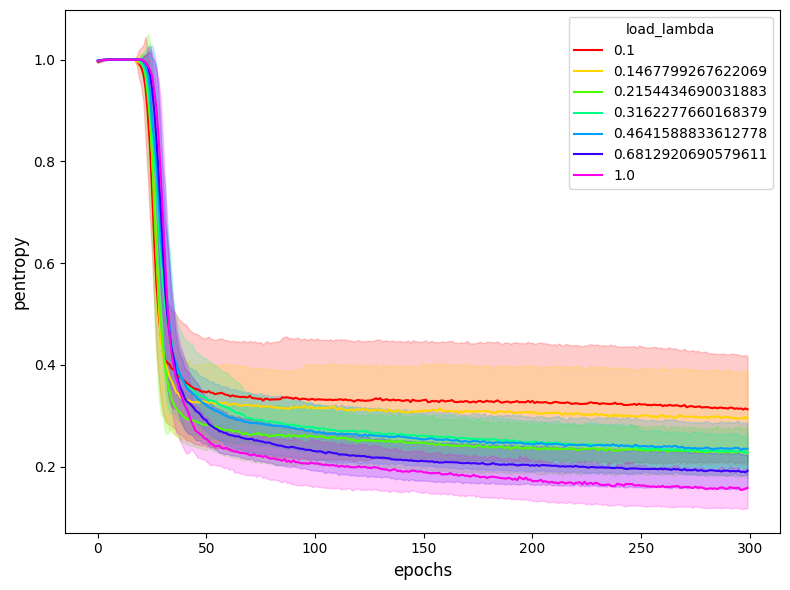

In [130]:
import matplotlib.pyplot as plt

def shaded_lines(df: pd.DataFrame, metric: str, group: str):
    means = df.groupby([group, "t"])[metric].mean()
    stds = df.groupby([group, "t"])[metric].std()

    means = means.unstack()
    stds = stds.unstack()

    means = means.sort_index(axis="columns")
    stds = stds.sort_index(axis="columns")

    fig, ax = plt.subplots(figsize=(8, 6))

    values_mu = means.to_numpy()
    values_std = stds.to_numpy()
    grouppers = means.index.to_numpy()
    colors = plt.colormaps["hsv"](np.arange(grouppers.size) / grouppers.size)
    epochs = values_mu.shape[1]
    epochs = np.arange(epochs)

    for i, (color, g) in enumerate(zip(colors, grouppers, strict=True)):
        ax.plot(epochs, values_mu[i, :], label=g, color=color)
        ax.fill_between(epochs, values_mu[i, :] + values_std[i, :], values_mu[i, :] - values_std[i, :], color=color, alpha=0.2)

    # ax.set_xscale("log")
    ax.legend(title=group)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel("epochs", fontsize=12)
    fig.tight_layout()
    plt.show()

    return fig

fig = shaded_lines(df, "pentropy", "load_lambda")
fig.savefig("./figures/exp_param_accuracy.pdf")


In [80]:
df["ratio"].unique()

array(['1:2:1', '2:1:1', '1:4:4', '4:1:4', '4:1:1', '4:4:1', '1:1:2',
       '1:2:2', '2:1:2', '2:2:1', '1:1:4', '1:1:1', '1:4:1'], dtype=object)

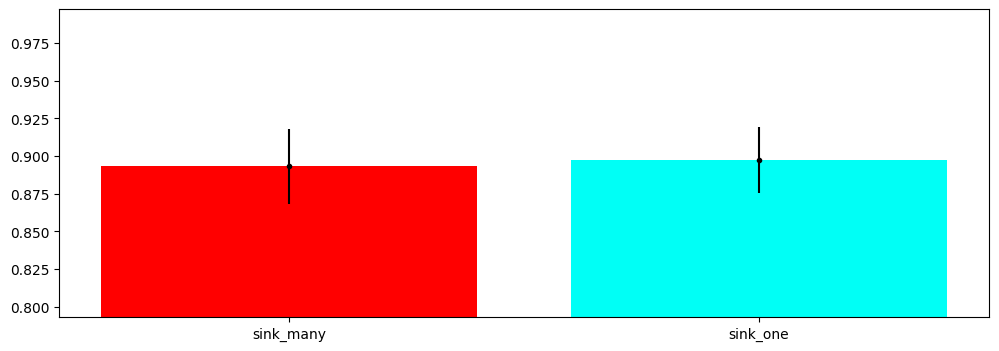

In [133]:

plot_metric = "test_accuracy"
group = "solver"

last_t = df.groupby(group)["t"].max()
last_t = last_t.unique()
assert last_t.size == 1
last_t = last_t[0]

last_df = df[df["t"] == last_t]

metrics = ["accuracy", "test_accuracy", "pentropy", "sentropy", "test_power_entropy", "test_speaker_entropy", "test_region_nmi"]

means = last_df.groupby(group)[metrics].mean().sort_index()
stds = last_df.groupby(group)[metrics].std().sort_index()

total_min = means[plot_metric].min()
total_max = means[plot_metric].max()

x_label = means.index.to_numpy()
x = np.arange(x_label.size)

colors = plt.colormaps["hsv"](np.arange(x.size) / x.size)

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(x, means[plot_metric], color=colors)

ax.set_ylim([max(total_min - 0.1, 0), total_max + 0.1])
ax.set_xticks(x, x_label)
ax.errorbar(x, means[plot_metric], stds[plot_metric], fmt='.', color='Black')

plt.show()

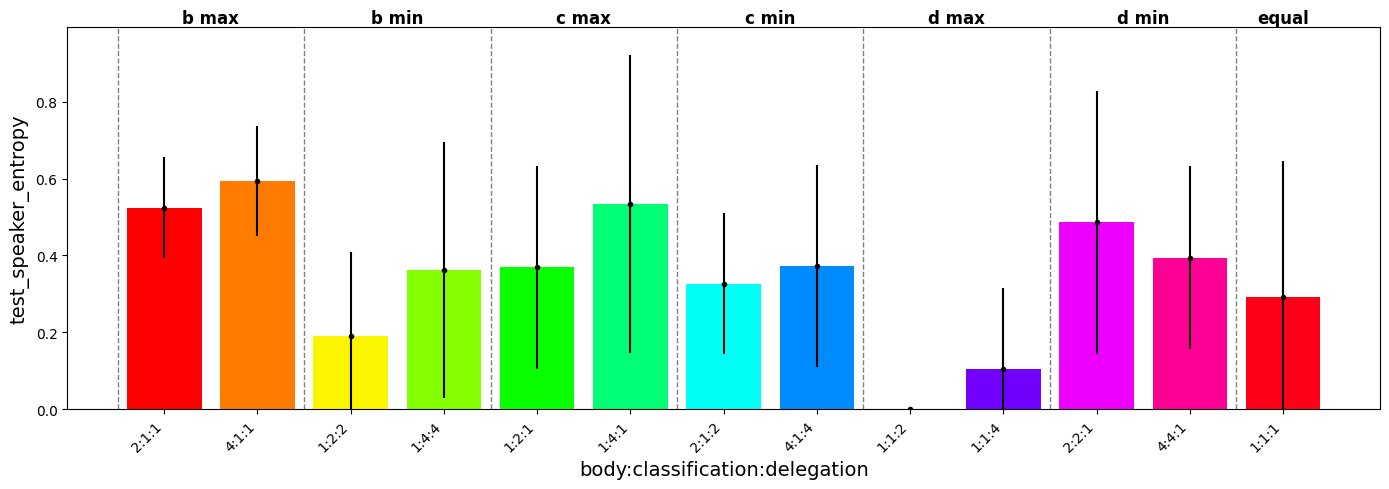

In [115]:
import numpy as np
import matplotlib.pyplot as plt

plot_metric = "test_speaker_entropy"

last_t = df.groupby("ratio")["t"].max()
last_t = last_t.unique()
assert last_t.size == 1
last_t = last_t[0]

last_df = df[df["t"] == last_t]

metrics = ["accuracy", "test_accuracy", "pentropy", "sentropy", "test_power_entropy", "test_speaker_entropy", "test_region_nmi"]

means = last_df.groupby(group)[metrics].mean().sort_index()
stds = last_df.groupby(group)[metrics].std().sort_index()

total_min = means[plot_metric].min()
total_max = means[plot_metric].max()

def classify_ratio(ratio_str):
    b, c, d = map(int, ratio_str.split(":"))
    vals = np.array([b, c, d])
    max_mask = vals == vals.max()
    min_mask = vals == vals.min()

    if max_mask.sum() == 1:
        return f"{['b','c','d'][np.argmax(max_mask)]} max"
    elif min_mask.sum() == 1:
        return f"{['b','c','d'][np.argmax(min_mask)]} min"
    else:
        return "equal"

means["group"] = means.index.map(classify_ratio)

ordered_means = means.sort_values(by=["group", "ratio"])
ordered_stds = stds.loc[ordered_means.index]

x_labels = ordered_means.index.to_list()
x = np.arange(len(x_labels))
colors = plt.colormaps["hsv"](np.linspace(0, 1, len(x)))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, ordered_means[plot_metric], color=colors)
ax.errorbar(x, ordered_means[plot_metric], ordered_stds[plot_metric], fmt='.', color='black')

ylim = [total_min - 0.1, total_max + 0.1]
if plot_metric == "test_accuracy":
    ylim[1] = total_max + 0.05
elif plot_metric == "test_region_nmi":
    ylim[1] = total_max + 0.3
elif plot_metric == "test_power_entropy":
    ylim[1] = total_max + 0.2
elif plot_metric == "test_speaker_entropy":
    ylim[1] = total_max + 0.4

ax.set_ylim((max(ylim[0], 0), ylim[1]))
ax.set_xticks(x, x_labels, rotation=45, ha='right')
ax.set_ylabel(plot_metric, fontsize=14)
ax.set_xlabel("body:classification:delegation", fontsize=14)

prev_group = None
group_positions = []
group_labels = []
for i, grp in enumerate(ordered_means["group"]):
    if grp != prev_group:
        group_positions.append(i)
        group_labels.append(grp)
        prev_group = grp

# Midpoints for labels
group_midpoints = [(start + (group_positions[i + 1] if i + 1 < len(group_positions) else len(x))) / 2 for i, start in enumerate(group_positions)]
for pos in group_positions:
    ax.axvline(pos - 0.5, color='gray', linestyle='--', linewidth=1)

# Add group names
for mid, label in zip(group_midpoints, group_labels):
    ax.text(mid - 0.5, ax.get_ylim()[1], label, ha='center', va='bottom', fontsize=12, fontweight='bold')


fig.tight_layout()
fig.savefig(f"./figures/ratio_{plot_metric}.pdf")

plt.show()
